# Métricas para Clasificación Multiclase

Este dataset contiene información sobre el consumo de alcohol de miles de participantes. Nuestro objetivo será clasificar a cada persona en uno de **tres niveles de consumo de alcohol**:

- **Clase 0 – Consumo leve**: bebe pocos días al mes (≤ 3 días) con pocas copas (≤ 2 por ocasión).
- **Clase 1 – Consumo moderado**: bebe con cierta regularidad, pero sin llegar a consumo elevado.
- **Clase 2 – Consumo elevado**: bebe muchos días (≥ 8 días/mes) o consume 5+ copas por ocasión.

Las **variables** que usaremos como características son:
- `ALQ121`: Frecuencia de consumo de alcohol en los últimos 12 meses (número de días/mes).
- `ALQ130`: Número promedio de bebidas por ocasión.

> 💡 Usaremos exactamente las mismas librerías y funciones del cuadernillo original, sin añadir ninguna adicional.

## Importaciones

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Carga y preparación del dataset ALQ_L

El archivo `.xpt` es un formato SAS utilizado frecuentemente por encuestas de salud pública como NHANES. Pandas puede leerlo directamente con `read_sas`.

In [35]:
df = pd.read_sas('ALQ_L.xpt', format='xport')
print(f'Dimensiones originales: {df.shape}')
df.head()

Dimensiones originales: (6337, 9)


,SEQN,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ151,ALQ170
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,1.0,2.000000e+00,3.0,5.397605e-79,NaN,NaN,2.0,NaN
2,130380.0,1.0,1.000000e+01,1.0,5.397605e-79,NaN,NaN,2.0,NaN
3,130386.0,1.0,4.000000e+00,2.0,1.000000e+01,5.397605e-79,10.0,2.0,5.397605e-79
4,130387.0,1.0,5.397605e-79,NaN,NaN,NaN,NaN,2.0,NaN


In [36]:
df.describe()

,SEQN,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ151,ALQ170
count,6337.000000,5481.000000,4.922000e+03,4069.000000,4.082000e+03,2.366000e+03,2.362000e+03,4901.000000,2.358000e+03
mean,136348.738362,1.109104,5.030679e+00,5.842959,4.742283e+00,4.838123e+00,3.545301e+00,1.821261,4.396098e+00
std,3439.132476,0.385114,4.314321e+00,54.996448,7.326042e+00,7.785415e+00,7.133496e+00,0.458352,4.525245e+01
min,130378.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,1.000000,5.397605e-79
25%,133337.000000,1.000000,2.000000e+00,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,2.000000,5.397605e-79
50%,136397.000000,1.000000,5.000000e+00,2.000000,4.000000e+00,4.000000e+00,5.397605e-79,2.000000,1.000000e+00
75%,139310.000000,1.000000,8.000000e+00,3.000000,9.000000e+00,9.000000e+00,7.000000e+00,2.000000,2.000000e+00
max,142310.000000,9.000000,9.900000e+01,999.000000,9.900000e+01,9.900000e+01,9.900000e+01,9.000000,9.990000e+02


### Limpieza de datos

- Filtramos solo personas que **sí beben** (`ALQ111 == 1`).
- Eliminamos filas con valores faltantes en las columnas de interés.
- Descartamos códigos especiales de "no sabe" (77, 99) y "rehúsa" (777, 999).
- Los valores de frecuencia extremadamente pequeños (notación científica ≈ 0) representan **0 días** y se tratan como tal.

In [37]:

# Solo bebedores
df_clean = df[df['ALQ111'] == 1].copy()

# Eliminar NaN en columnas clave
df_clean = df_clean.dropna(subset=['ALQ121', 'ALQ130'])

# Eliminar códigos especiales
df_clean = df_clean[~df_clean['ALQ130'].isin([777, 999])]
df_clean = df_clean[~df_clean['ALQ121'].isin([77, 99])]

# Tratar valores cuasi-cero
df_clean['ALQ121'] = df_clean['ALQ121'].apply(lambda x: 0.0 if x < 0.01 else x)

# Reemplazar valores basura en TODO el dataset limpio
df_clean = df_clean.replace(5.397605e-79, np.nan)

# Eliminar filas con NaN finales
df_clean = df_clean.dropna()

print(f'Registros tras limpieza: {df_clean.shape[0]}')

Registros tras limpieza: 2331


### Creación de la variable objetivo multiclase

Definimos tres clases de consumo de alcohol basadas en la **frecuencia** (`ALQ121`) y el **promedio de copas por ocasión** (`ALQ130`):

| Clase | Etiqueta | Criterio |
|-------|----------|----------|
| 0 | Consumo leve | Frecuencia ≤ 3 días/mes **y** ≤ 2 copas/ocasión |
| 1 | Consumo moderado | Resto de casos |
| 2 | Consumo elevado | Frecuencia ≥ 8 días/mes **o** ≥ 5 copas/ocasión |

In [38]:
def clasificar_consumo(row):
    freq   = row['ALQ121']
    drinks = row['ALQ130']
    if drinks >= 5 or freq >= 8:
        return 2  # Elevado
    elif freq <= 3 and drinks <= 2:
        return 0  # Leve
    else:
        return 1  # Moderado

df_clean['target'] = df_clean.apply(clasificar_consumo, axis=1)

print('Distribución de clases:')
print(df_clean['target'].value_counts().sort_index())
print()
print('Proporción de clases:')
print((df_clean['target'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + ' %')

Distribución de clases:
target
0     299
1    1199
2     833
Name: count, dtype: int64

Proporción de clases:
target
0    12.83 %
1    51.44 %
2    35.74 %
Name: proportion, dtype: str


## División en entrenamiento y test

Usamos `train_test_split` de scikit-learn, con estratificación para respetar la distribución de clases en ambos subconjuntos.

In [39]:
features = [
    'ALQ111',
    'ALQ142',
    'ALQ151',
    'ALQ170',
    'ALQ270',
    'ALQ280'
]

X = df_clean[features].values
y = df_clean['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')

Entrenamiento: 1864 muestras
Test:          467 muestras


## Entrenamiento del clasificador

Usamos un `DecisionTreeClassifier`, uno de los modelos clásicos de scikit-learn. En clasificación multiclase no necesitamos hacer ninguna adaptación especial: scikit-learn lo maneja de forma nativa.

In [40]:
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Primeras 10 predicciones:', y_pred[:10])
print('Primeras 10 etiquetas reales:', y_test[:10])

Primeras 10 predicciones: [1 1 1 2 2 1 1 1 1 1]
Primeras 10 etiquetas reales: [0 2 2 1 1 2 0 0 1 2]


## Métricas

### *Accuracy*

In [41]:
def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)

acc_manual = accuracy(y_pred, y_test)
print(f'Accuracy (manual):      {acc_manual:.4f}')

Accuracy (manual):      0.5653


In [42]:
acc_sklearn = accuracy_score(y_test, y_pred)
print(f'Accuracy (sklearn):     {acc_sklearn:.4f}')

Accuracy (sklearn):     0.5653


**Interpretación:** Una accuracy de, por ejemplo, `0.83` significa que el modelo acierta aproximadamente 8 de cada 10 muestras. Sin embargo, dado que la clase 0 (consumo leve) es menos frecuente que las demás, este valor puede estar inflado por el buen desempeño en las clases mayoritarias. Necesitamos métricas por clase para un diagnóstico completo.

### La Matriz de Confusión

La matriz de confusión es la herramienta de diagnóstico más informativa para clasificación multiclase. Se trata de una matriz $C \times C$ (donde $C$ es el número de clases) en la que:

- **Fila $i$**: muestras cuya **etiqueta real** es la clase $i$.
- **Columna $j$**: muestras que el modelo **predijo** como clase $j$.

Los elementos de la **diagonal principal** representan las predicciones correctas. Los elementos **fuera de la diagonal** son los errores: nos dicen con qué clase confunde el modelo a cada clase real.

En el caso multiclase no hay un único TP/TN/FP/FN global; en cambio, para cada clase $k$ se puede calcular:
- $TP_k$: muestras de la clase $k$ predichas como $k$.
- $FP_k$: muestras de otra clase predichas como $k$.
- $FN_k$: muestras de la clase $k$ predichas como otra clase.

In [43]:
clases = [0, 1, 2]
n = len(clases)

CM = np.zeros((n, n), dtype=int)
for i in clases:
    for j in clases:
        CM[i, j] = np.sum((y_test == i) & (y_pred == j))

print('Matriz de Confusión (manual):')
print('          Pred 0   Pred 1   Pred 2')
for i, row in enumerate(CM):
    print(f'Real {i}:  ', '  '.join(f'{v:6d}' for v in row))

Matriz de Confusión (manual):
          Pred 0   Pred 1   Pred 2
Real 0:        0      54       6
Real 1:        1     205      34
Real 2:        1     107      59


In [44]:
CM_sklearn = confusion_matrix(y_test, y_pred)
print('Matriz de Confusión (sklearn):')
print(CM_sklearn)

Matriz de Confusión (sklearn):
[[  0  54   6]
 [  1 205  34]
 [  1 107  59]]


**Interpretación:** La diagonal muestra cuántas muestras de cada clase fueron bien clasificadas. Los valores fuera de la diagonal revelan los errores. Por ejemplo, si hay muchos valores altos en la fila de la clase 1 pero en la columna de la clase 2, significa que el modelo tiende a sobre-predecir consumo elevado en personas que realmente son moderadas. Este análisis ayuda a identificar hacia dónde hay que mejorar el modelo.

### *Precision* y *Recall*

In [45]:
def precision_por_clase(y_pred, y, clase):
    TP = np.sum((y_pred == clase) & (y == clase))
    FP = np.sum((y_pred == clase) & (y != clase))
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def recall_por_clase(y_pred, y, clase):
    TP = np.sum((y_pred == clase) & (y == clase))
    FN = np.sum((y_pred != clase) & (y == clase))
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

nombres_clase = {0: 'Leve', 1: 'Moderado', 2: 'Elevado'}

print(f"{'Clase':<12} {'Precision':>10} {'Recall':>10}")
print('-' * 35)

for c in clases:
    p = precision_por_clase(y_pred, y_test, c)
    r = recall_por_clase(y_pred, y_test, c)
    print(f"{nombres_clase[c]:<12} {p:>10.4f} {r:>10.4f}")

Clase         Precision     Recall
-----------------------------------
Leve             0.0000     0.0000
Moderado         0.5601     0.8542
Elevado          0.5960     0.3533


In [46]:
for avg in ['macro', 'weighted', 'micro']:
    p = precision_score(y_test, y_pred, average=avg)
    r = recall_score(y_test, y_pred, average=avg)
    print(f'[{avg:>8}]  Precision: {p:.4f}   Recall: {r:.4f}')

[   macro]  Precision: 0.3854   Recall: 0.4025
[weighted]  Precision: 0.5010   Recall: 0.5653
[   micro]  Precision: 0.5653   Recall: 0.5653


**Interpretación:** 
- Una *precision* baja en la clase 0 (leve) indicaría que el modelo confunde otras clases con «leve», generando muchos falsos positivos para esa categoría.
- Un *recall* bajo en la clase 2 (elevado) indicaría que el modelo falla en detectar personas con consumo elevado, lo cual sería preocupante si el objetivo fuera identificar patrones de riesgo.
- La diferencia entre `macro` y `weighted` revela el efecto del desbalanceo de clases: si difieren mucho, las clases minoritarias tienen un desempeño distinto al global.

### F1-Score

In [47]:
print(f"{'Clase':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('-' * 45)

for c in clases:
    p = precision_por_clase(y_pred, y_test, c)
    r = recall_por_clase(y_pred, y_test, c)
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
    print(f"{nombres_clase[c]:<12} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

Clase         Precision     Recall         F1
---------------------------------------------
Leve             0.0000     0.0000     0.0000
Moderado         0.5601     0.8542     0.6766
Elevado          0.5960     0.3533     0.4436


In [48]:
for avg in ['macro', 'weighted', 'micro']:
    f1 = f1_score(y_test, y_pred, average=avg)
    print(f'F1-Score [{avg:>8}]: {f1:.4f}')

F1-Score [   macro]: 0.3734
F1-Score [weighted]: 0.5063
F1-Score [   micro]: 0.5653


**Interpretación:** Un F1 macro bajo (significativamente menor que el F1 weighted) señala que el modelo falla especialmente en las clases minoritarias. Si el F1 de la clase 0 (leve, la menos frecuente) es notablemente inferior al de las demás, se recomienda aplicar técnicas de balanceo de clases o ajustar los pesos del modelo.

### La curva ROC y el AUC

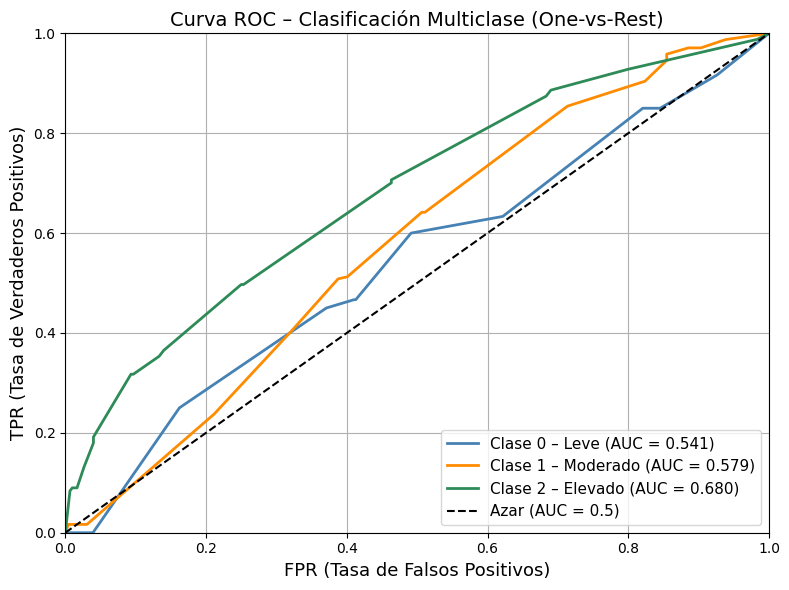

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
%matplotlib inline

# Probabilidades predichas por clase
y_prob = clf.predict_proba(X_test)

# Binarizar etiquetas para OvR
y_test_bin = label_binarize(y_test, classes=clases)

plt.figure(figsize=(8, 6))
colores = ['steelblue', 'darkorange', 'seagreen']

for i, c in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, linewidth=2, color=colores[i],
             label=f'Clase {c} – {nombres_clase[c]} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.axis([0, 1, 0, 1])
plt.xlabel('FPR (Tasa de Falsos Positivos)', fontsize=13)
plt.ylabel('TPR (Tasa de Verdaderos Positivos)', fontsize=13)
plt.title('Curva ROC – Clasificación Multiclase (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
# AUC macro y weighted (promedio entre clases)
auc_macro    = roc_auc_score(y_test_bin, y_prob, average='macro')
auc_weighted = roc_auc_score(y_test_bin, y_prob, average='weighted')

print(f'AUC-ROC macro:    {auc_macro:.4f}')
print(f'AUC-ROC weighted: {auc_weighted:.4f}')

AUC-ROC macro:    0.6000
AUC-ROC weighted: 0.6103


**Interpretación:** 
- Un AUC cercano a 1 en todas las clases indica que el clasificador discrimina bien entre cada clase y el resto.
- Si el AUC de la clase 0 (leve) es inferior al de las demás, el modelo tiene más dificultad para separar el consumo leve del moderado, lo que tiene sentido dada su menor representación en el dataset.
- La diferencia entre AUC `macro` y `weighted` refleja nuevamente el impacto del desbalanceo de clases.

## Resumen completo con `classification_report`

Scikit-learn ofrece una función que consolida *precision*, *recall* y *F1* por clase y sus promedios en un único reporte legible.

In [51]:
print('Reporte de Clasificación:')
print(classification_report(
    y_test, y_pred,
    target_names=['Leve (0)', 'Moderado (1)', 'Elevado (2)']
))

Reporte de Clasificación:
              precision    recall  f1-score   support

    Leve (0)       0.00      0.00      0.00        60
Moderado (1)       0.56      0.85      0.68       240
 Elevado (2)       0.60      0.35      0.44       167

    accuracy                           0.57       467
   macro avg       0.39      0.40      0.37       467
weighted avg       0.50      0.57      0.51       467

